# FTM Multilateration Analysis

This notebook analyzes Fine Timing Measurement (FTM) data from a multilateration setup with:
- **4 fixed responders** at known positions
- **1 mobile initiator** measured at 8 different positions

## Room Layout (20m × 10m)
```
 (0,10)                   (20,10)
    r3 ────────────────────── r4
    │                         │
    │    p31    p32    p33    │
    │                         │
    │    p21    p22           │
    │                         │
    │    p11    p12    p13    │
    │                         │
    r1 ────────────────────── r2 
  (0,0)                    (20,0)
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, FancyArrowPatch
from pathlib import Path
from scipy.optimize import least_squares
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

## 1. Load and Parse Data

Load all position CSV files, handling the comment headers and error lines.

In [12]:
# Define paths
DATA_DIR = Path("data/ftm_quad_tests")

# Responder positions (in meters)
RESPONDERS = {
    'r1': (0.0, 0.0),
    'r2': (20.0, 0.0),
    'r3': (0.0, 10.0),
    'r4': (20.0, 10.0)
}

def load_ftm_csv(filepath):
    """Load FTM CSV file, skipping comment lines and error messages."""
    # Read all lines, filter out comments and error lines
    valid_lines = []
    with open(filepath, 'r') as f:
        for line in f:
            # Skip comment lines and error messages
            if line.startswith('#') or line.startswith('E ') or line.startswith('W '):
                continue
            valid_lines.append(line)
    
    # Parse as CSV
    from io import StringIO
    df = pd.read_csv(StringIO(''.join(valid_lines)))
    return df

# Load all position files
position_files = sorted(DATA_DIR.glob("FTM_QUAD_espaceSAT_pos*.csv"))
print(f"Found {len(position_files)} position files:")
for f in position_files:
    print(f"  - {f.name}")

# Combine all data
all_data = []
for filepath in position_files:
    df = load_ftm_csv(filepath)
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)
print(f"\nTotal samples loaded: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")

Found 8 position files:
  - FTM_QUAD_espaceSAT_pos11.csv
  - FTM_QUAD_espaceSAT_pos12.csv
  - FTM_QUAD_espaceSAT_pos13.csv
  - FTM_QUAD_espaceSAT_pos21.csv
  - FTM_QUAD_espaceSAT_pos22.csv
  - FTM_QUAD_espaceSAT_pos31.csv
  - FTM_QUAD_espaceSAT_pos32.csv
  - FTM_QUAD_espaceSAT_pos33.csv

Total samples loaded: 31576
Columns: ['position', 'real_x', 'real_y', 'responder_ssid', 'responder_label', 'responder_x', 'responder_y', 'frame_count', 'burst_period', 'dist_est_cm', 'rtt_est_ns', 'rssi', 'elapsed_ms', 'sample_num']


In [13]:
# Preview the data
df_all.head(12)

,position,real_x,real_y,responder_ssid,responder_label,responder_x,responder_y,frame_count,burst_period,dist_est_cm,rtt_est_ns,rssi,elapsed_ms,sample_num
0,p11,5.0,2.5,ftm_responder_001,r1,0.0,0.0,16,4,735,49,-37,483,1
1,p11,5.0,2.5,ftm_responder_002,r2,20.0,0.0,16,4,1650,110,-44,448,1
2,p11,5.0,2.5,ftm_responder_003,r3,0.0,10.0,16,4,1065,71,-35,517,1
3,p11,5.0,2.5,ftm_responder_004,r4,20.0,10.0,16,4,2835,189,-51,528,1
4,p11,5.0,2.5,ftm_responder_001,r1,0.0,0.0,16,4,840,56,-37,453,2
5,p11,5.0,2.5,ftm_responder_002,r2,20.0,0.0,16,4,1695,113,-45,435,2
6,p11,5.0,2.5,ftm_responder_003,r3,0.0,10.0,16,4,1065,71,-35,530,2
7,p11,5.0,2.5,ftm_responder_004,r4,20.0,10.0,16,4,2850,190,-51,525,2
8,p11,5.0,2.5,ftm_responder_001,r1,0.0,0.0,16,4,825,55,-37,445,3
9,p11,5.0,2.5,ftm_responder_002,r2,20.0,0.0,16,4,1800,120,-44,448,3


## 2. Calculate True Distances and Errors

For each measurement, calculate:
- **True distance**: $d_{true} = \sqrt{(x_{init} - x_{resp})^2 + (y_{init} - y_{resp})^2}$
- **Error**: $\epsilon = d_{estimated} - d_{true}$

In [17]:
# Calculate true distance (convert positions from meters to cm for comparison)
df_all['true_dist_cm'] = np.sqrt(
    (df_all['real_x'] * 100 - df_all['responder_x'] * 100)**2 +
    (df_all['real_y'] * 100 - df_all['responder_y'] * 100)**2
)

# Calculate error (estimated - true)
df_all['error_cm'] = df_all['dist_est_cm'] - df_all['true_dist_cm']
df_all['abs_error_cm'] = np.abs(df_all['error_cm'])
df_all['error_percent'] = (df_all['error_cm'] / df_all['true_dist_cm']) * 100

# Display summary statistics
print("=" * 60)
print("DISTANCE ERROR SUMMARY")
print("=" * 60)
print(f"\nOverall Statistics:")
print(f"  Mean Error:      {df_all['error_cm'].mean():+.1f} cm")
print(f"  Std Dev:         {df_all['error_cm'].std():.1f} cm")
print(f"  Mean Abs Error:  {df_all['abs_error_cm'].mean():.1f} cm")
print(f"  Median Error:    {df_all['error_cm'].median():+.1f} cm")

# Per-position statistics
print(f"\nPer-Position Statistics:")
pos_stats = df_all.groupby('position').agg({
    'error_cm': ['mean', 'std'],
    'abs_error_cm': 'mean',
    'true_dist_cm': 'mean'
}).round(1)
print(pos_stats)

DISTANCE ERROR SUMMARY

Overall Statistics:
  Mean Error:      +502.9 cm
  Std Dev:         478.3 cm
  Mean Abs Error:  522.6 cm
  Median Error:    +341.0 cm

Per-Position Statistics:
         error_cm        abs_error_cm true_dist_cm
             mean    std         mean         mean
position                                          
p11         419.4  527.5        445.5       1163.5
p12         524.4  289.4        524.9       1140.1
p13         428.2  334.4        436.5       1164.3
p21         377.9  526.1        422.3       1144.1
p22         352.8  323.0        361.6       1118.0
p31         702.0  658.8        769.1       1166.2
p32         660.7  568.3        661.8       1140.4
p33         557.6  319.4        559.4       1167.5


In [ ]:
# Per-responder statistics
print("\nPer-Responder Statistics:")
resp_stats = df_all.groupby('responder_label').agg({
    'error_cm': ['mean', 'std'],
    'abs_error_cm': 'mean',
    'rssi': 'mean'
}).round(1)
print(resp_stats)

## 2b. Sample Completeness & Methodology Validation

**Critical Question**: Does our current approach of skipping error lines introduce bias?

When a responder fails (e.g., `# ERROR round 5: ftm_responder_002 (r2) — timeout/failure`):
- We still load the 3 successful measurements for that sample_num
- These "incomplete" samples mix with "complete" (4-responder) samples
- Failed measurements often correlate with difficult conditions → excluding them could make stats look artificially better

**This section analyzes:**
1. Sample completeness distribution
2. Error rate per responder (how often each one fails)
3. Comparison of complete vs incomplete sample accuracy
4. Recommendations for methodology

In [18]:
# Analyze sample completeness
# For each (position, sample_num) combination, count how many responders we have

sample_completeness = df_all.groupby(['position', 'sample_num']).agg({
    'responder_label': 'count',
    'real_x': 'first',
    'real_y': 'first'
}).rename(columns={'responder_label': 'n_responders'})

sample_completeness = sample_completeness.reset_index()

# Distribution of sample completeness
completeness_dist = sample_completeness['n_responders'].value_counts().sort_index()

print("=" * 60)
print("SAMPLE COMPLETENESS ANALYSIS")
print("=" * 60)
print("\n📊 Distribution of responders per sample:")
for n_resp, count in completeness_dist.items():
    pct = 100 * count / len(sample_completeness)
    status = "✓ Complete" if n_resp == 4 else "⚠ Incomplete"
    print(f"   {n_resp} responders: {count:5d} samples ({pct:5.1f}%) {status}")

total_samples = len(sample_completeness)
complete_samples = (sample_completeness['n_responders'] == 4).sum()
incomplete_samples = total_samples - complete_samples
print(f"\n   Total sample cycles: {total_samples}")
print(f"   Complete (4/4):      {complete_samples} ({100*complete_samples/total_samples:.1f}%)")
print(f"   Incomplete (<4):     {incomplete_samples} ({100*incomplete_samples/total_samples:.1f}%)")

SAMPLE COMPLETENESS ANALYSIS

📊 Distribution of responders per sample:
   2 responders:     4 samples (  0.1%) ⚠ Incomplete
   3 responders:   416 samples (  5.2%) ⚠ Incomplete
   4 responders:  7580 samples ( 94.8%) ✓ Complete

   Total sample cycles: 8000
   Complete (4/4):      7580 (94.8%)
   Incomplete (<4):     420 (5.2%)


In [15]:
# Calculate per-responder failure rate
# We need to count expected vs actual measurements per responder

# Expected: each responder should appear once per sample_num per position
expected_per_responder = len(sample_completeness)  # total sample cycles

responder_counts = df_all.groupby('responder_label').size()
responder_failure_rate = {}

print("\n📡 PER-RESPONDER FAILURE RATE:")
print("-" * 50)
for resp in ['r1', 'r2', 'r3', 'r4']:
    actual = responder_counts.get(resp, 0)
    failures = expected_per_responder - actual
    failure_rate = 100 * failures / expected_per_responder
    responder_failure_rate[resp] = failure_rate
    
    # Get mean RSSI for context
    mean_rssi = df_all[df_all['responder_label'] == resp]['rssi'].mean()
    
    print(f"   {resp}: {failures:4d} failures / {expected_per_responder} expected = {failure_rate:5.2f}% failure rate (mean RSSI: {mean_rssi:.1f} dBm)")

print("\n💡 Interpretation:")
print("   - Higher failure rate often correlates with weaker signal (lower RSSI)")
print("   - Failed measurements represent 'worst case' scenarios that are EXCLUDED from our stats")
print("   - This creates a POSITIVE BIAS in reported accuracy (real performance is worse)")


📡 PER-RESPONDER FAILURE RATE:
--------------------------------------------------
   r1:   83 failures / 8000 expected =  1.04% failure rate (mean RSSI: -41.4 dBm)
   r2:  113 failures / 8000 expected =  1.41% failure rate (mean RSSI: -45.0 dBm)
   r3:  108 failures / 8000 expected =  1.35% failure rate (mean RSSI: -34.7 dBm)
   r4:  120 failures / 8000 expected =  1.50% failure rate (mean RSSI: -49.7 dBm)

💡 Interpretation:
   - Higher failure rate often correlates with weaker signal (lower RSSI)
   - Failed measurements represent 'worst case' scenarios that are EXCLUDED from our stats
   - This creates a POSITIVE BIAS in reported accuracy (real performance is worse)


In [19]:
# Compare error statistics: Complete samples vs Incomplete samples

# Tag each measurement with whether its sample is complete
sample_completeness_lookup = sample_completeness.set_index(['position', 'sample_num'])['n_responders']
df_all['sample_n_responders'] = df_all.apply(
    lambda row: sample_completeness_lookup.get((row['position'], row['sample_num']), 0), 
    axis=1
)
df_all['is_complete_sample'] = df_all['sample_n_responders'] == 4

print("\n📏 DISTANCE ERROR: Complete vs Incomplete Samples")
print("-" * 60)

for is_complete, label in [(True, "Complete (4/4 responders)"), (False, "Incomplete (<4 responders)")]:
    mask = df_all['is_complete_sample'] == is_complete
    subset = df_all[mask]
    
    if len(subset) > 0:
        print(f"\n   {label}:")
        print(f"      Measurements: {len(subset):,}")
        print(f"      Mean error:   {subset['error_cm'].mean():+.1f} cm")
        print(f"      Std dev:      {subset['error_cm'].std():.1f} cm")
        print(f"      Mean |error|: {subset['abs_error_cm'].mean():.1f} cm")
        print(f"      Mean RSSI:    {subset['rssi'].mean():.1f} dBm")

# Statistical test: are they significantly different?
complete_errors = df_all[df_all['is_complete_sample']]['abs_error_cm']
incomplete_errors = df_all[~df_all['is_complete_sample']]['abs_error_cm']

if len(incomplete_errors) > 10:
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(complete_errors, incomplete_errors)
    print(f"\n   📊 T-test (complete vs incomplete): p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("      → Statistically SIGNIFICANT difference!")
    else:
        print("      → No significant difference detected.")


📏 DISTANCE ERROR: Complete vs Incomplete Samples
------------------------------------------------------------

   Complete (4/4 responders):
      Measurements: 30,320
      Mean error:   +502.6 cm
      Std dev:      475.9 cm
      Mean |error|: 522.6 cm
      Mean RSSI:    -42.7 dBm

   Incomplete (<4 responders):
      Measurements: 1,256
      Mean error:   +509.0 cm
      Std dev:      533.4 cm
      Mean |error|: 522.7 cm
      Mean RSSI:    -42.7 dBm

   📊 T-test (complete vs incomplete): p-value = 0.9964
      → No significant difference detected.


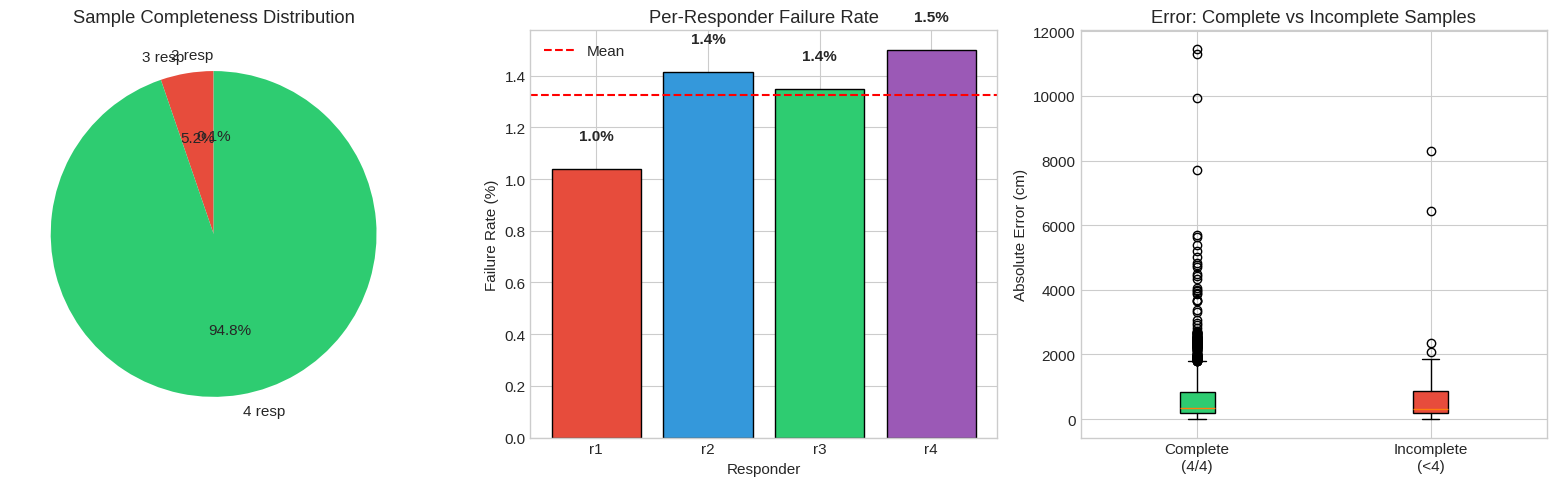

In [20]:
# Visualize completeness analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Pie chart of sample completeness
ax1 = axes[0]
labels = [f'{n} resp' for n in completeness_dist.index]
colors = ['#2ecc71' if n == 4 else '#e74c3c' for n in completeness_dist.index]
ax1.pie(completeness_dist.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Sample Completeness Distribution')

# 2. Bar chart of failure rate per responder
ax2 = axes[1]
resp_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
bars = ax2.bar(['r1', 'r2', 'r3', 'r4'], 
               [responder_failure_rate[r] for r in ['r1', 'r2', 'r3', 'r4']],
               color=resp_colors, edgecolor='black')
ax2.set_ylabel('Failure Rate (%)')
ax2.set_xlabel('Responder')
ax2.set_title('Per-Responder Failure Rate')
ax2.axhline(y=np.mean(list(responder_failure_rate.values())), color='red', 
            linestyle='--', label='Mean')
ax2.legend()

# Add value labels on bars
for bar, rate in zip(bars, [responder_failure_rate[r] for r in ['r1', 'r2', 'r3', 'r4']]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Box plot comparing complete vs incomplete
ax3 = axes[2]
data_to_plot = [
    df_all[df_all['is_complete_sample']]['abs_error_cm'],
    df_all[~df_all['is_complete_sample']]['abs_error_cm']
]
bp = ax3.boxplot(data_to_plot, labels=['Complete\n(4/4)', 'Incomplete\n(<4)'], 
                  patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax3.set_ylabel('Absolute Error (cm)')
ax3.set_title('Error: Complete vs Incomplete Samples')

plt.tight_layout()
plt.show()

In [21]:
# Multilateration comparison: 4-responder vs 3-responder (trilateration)
print("\n🎯 MULTILATERATION: Complete vs Trilateration Fallback")
print("-" * 60)

# Filter df_results by number of responders used
multilat_4 = df_results[df_results['n_responders'] == 4]
multilat_3 = df_results[df_results['n_responders'] == 3]

print(f"\n   4-responder multilateration:")
print(f"      Samples:    {len(multilat_4):,}")
print(f"      Mean error: {multilat_4['pos_error_m'].mean():.3f} m")
print(f"      Std dev:    {multilat_4['pos_error_m'].std():.3f} m")
print(f"      Median:     {multilat_4['pos_error_m'].median():.3f} m")

if len(multilat_3) > 0:
    print(f"\n   3-responder trilateration (fallback):")
    print(f"      Samples:    {len(multilat_3):,}")
    print(f"      Mean error: {multilat_3['pos_error_m'].mean():.3f} m")
    print(f"      Std dev:    {multilat_3['pos_error_m'].std():.3f} m")
    print(f"      Median:     {multilat_3['pos_error_m'].median():.3f} m")
    
    # Check if significantly different
    if len(multilat_3) > 10:
        t_stat, p_value = stats.ttest_ind(multilat_4['pos_error_m'], multilat_3['pos_error_m'])
        print(f"\n   📊 T-test (4-resp vs 3-resp): p-value = {p_value:.4f}")
else:
    print("\n   No 3-responder samples to compare (all samples complete).")


🎯 MULTILATERATION: Complete vs Trilateration Fallback
------------------------------------------------------------

   4-responder multilateration:
      Samples:    7,580
      Mean error: 5.152 m
      Std dev:    1.970 m
      Median:     5.164 m

   3-responder trilateration (fallback):
      Samples:    416
      Mean error: 5.575 m
      Std dev:    2.355 m
      Median:     5.226 m

   📊 T-test (4-resp vs 3-resp): p-value = 0.0000


### Methodology Recommendations

Based on the completeness analysis above:

**Current Approach (what we do):**
- Skip error/comment lines during CSV parsing
- Include all valid measurements regardless of sample completeness
- Fall back to trilateration when only 3 responders available

**Potential Biases:**
1. **Survivorship bias**: Failed measurements (often from difficult conditions) are excluded → reported accuracy is optimistic
2. **Selection bias**: If certain positions consistently lose one responder, the stats for that position are based on "easier" conditions

**Recommendations:**
1. ✅ **Report sample completeness rate** (done above) - shows system reliability
2. ✅ **Compare complete vs incomplete** (done above) - quantifies bias
3. ⚠️ **Consider worst-case analysis**: For critical applications, assume failed measurements would have been worse than median
4. ⚠️ **Per-position failure analysis**: Track which positions/responders fail most
5. ✅ **Report failure rates alongside accuracy** - gives complete picture of system performance

### Hardware Configuration Notes

| Responder | Hardware | Antenna | Position | Notes |
|-----------|----------|---------|----------|-------|
| **r1** | Adafruit Feather ESP32-S3 TFT | PCB antenna | (0, 0) | Corner |
| **r2** | Adafruit Feather ESP32-S3 TFT | PCB antenna | (20, 0) | Near windows/doors |
| **r3** | Seeed XIAO ESP32-S3 | External u.FL mini nanoblade | (0, 10) | Best performer ✓ |
| **r4** | Adafruit Feather ESP32-S3 | PCB antenna | (20, 10) | Worst performer ✗ |

**Observations:**
- r3's external antenna significantly improves both RSSI and accuracy
- r2's position near windows/doors likely causes multipath interference
- r4's poor performance despite same hardware as r1/r2 suggests environmental factors

## 3. Visualize Room Layout with Positions

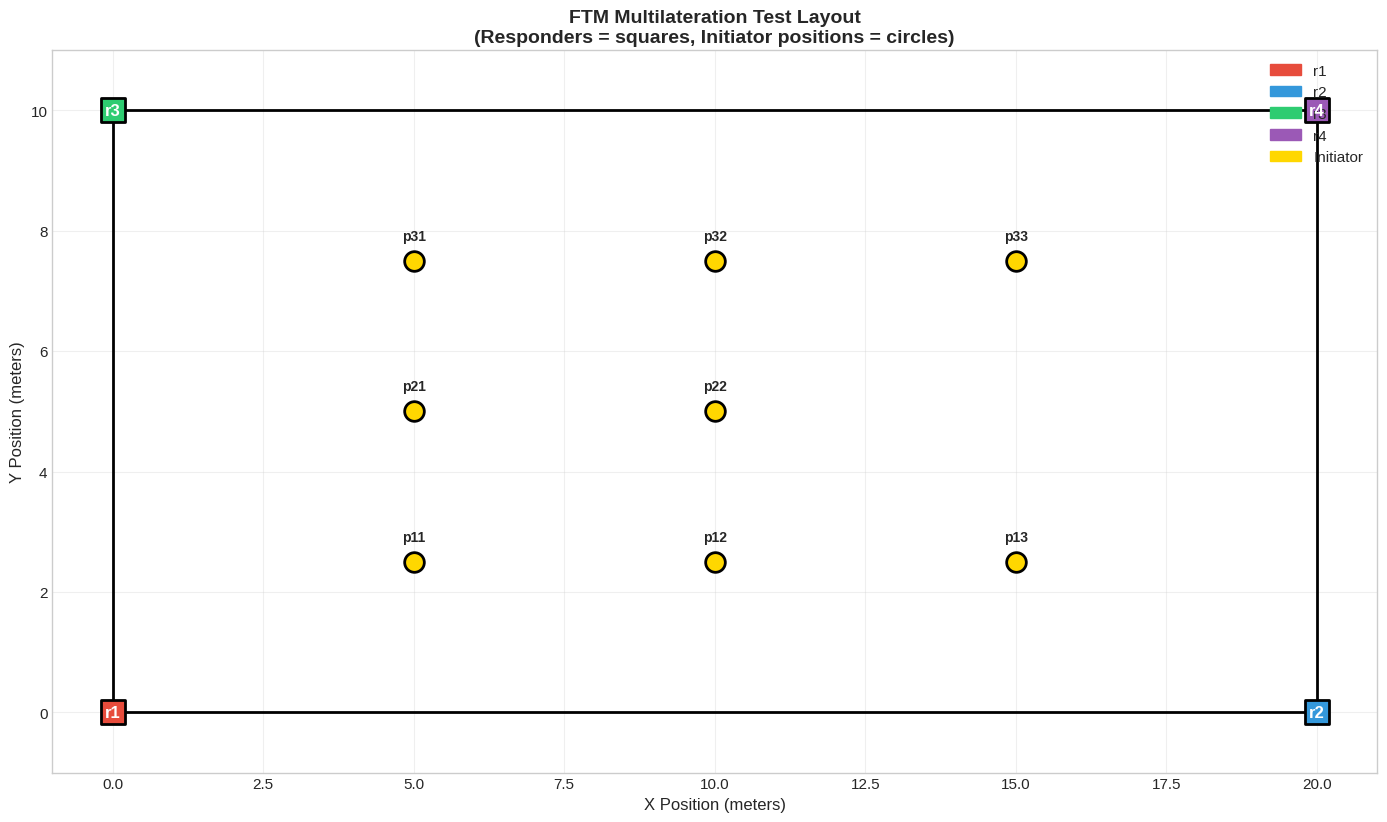

In [4]:
def plot_room_layout():
    """Plot the room layout with responders and initiator positions."""
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # Room boundary
    room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(room)
    
    # Plot responders
    resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71', 'r4': '#9b59b6'}
    for label, (x, y) in RESPONDERS.items():
        ax.scatter(x, y, s=300, c=resp_colors[label], marker='s', 
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(label, (x, y), fontsize=12, fontweight='bold',
                    ha='center', va='center', color='white', zorder=6)
    
    # Get unique initiator positions
    positions = df_all.groupby('position')[['real_x', 'real_y']].first().reset_index()
    
    # Plot initiator positions
    for _, row in positions.iterrows():
        ax.scatter(row['real_x'], row['real_y'], s=200, c='gold', 
                   marker='o', edgecolor='black', linewidth=2, zorder=4)
        ax.annotate(row['position'], (row['real_x'], row['real_y']), 
                    xytext=(0, 15), textcoords='offset points',
                    fontsize=10, ha='center', fontweight='bold')
    
    # Add grid
    ax.set_xlim(-1, 21)
    ax.set_ylim(-1, 11)
    ax.set_xlabel('X Position (meters)', fontsize=12)
    ax.set_ylabel('Y Position (meters)', fontsize=12)
    ax.set_title('FTM Multilateration Test Layout\n(Responders = squares, Initiator positions = circles)', 
                 fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # Legend
    legend_elements = [mpatches.Patch(color=c, label=l) for l, c in resp_colors.items()]
    legend_elements.append(mpatches.Patch(color='gold', label='Initiator'))
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    return fig, ax

fig, ax = plot_room_layout()
plt.show()

## 4. Distance Error Distribution

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of errors
ax1 = axes[0, 0]
ax1.hist(df_all['error_cm'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax1.axvline(x=df_all['error_cm'].mean(), color='orange', linestyle='-', linewidth=2, 
            label=f'Mean: {df_all["error_cm"].mean():.1f} cm')
ax1.set_xlabel('Error (cm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Distance Errors')
ax1.legend()

# 2. Box plot by responder
ax2 = axes[0, 1]
resp_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
bp = df_all.boxplot(column='error_cm', by='responder_label', ax=ax2, 
                    patch_artist=True, return_type='dict')
for patch, color in zip(bp['error_cm']['boxes'], resp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('Responder')
ax2.set_ylabel('Error (cm)')
ax2.set_title('Error Distribution by Responder')
plt.suptitle('')

# 3. Box plot by position
ax3 = axes[1, 0]
df_all.boxplot(column='error_cm', by='position', ax=ax3)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.set_xlabel('Position')
ax3.set_ylabel('Error (cm)')
ax3.set_title('Error Distribution by Position')
plt.suptitle('')

# 4. Error vs True Distance
ax4 = axes[1, 1]
for resp in ['r1', 'r2', 'r3', 'r4']:
    mask = df_all['responder_label'] == resp
    ax4.scatter(df_all.loc[mask, 'true_dist_cm'], df_all.loc[mask, 'error_cm'], 
                alpha=0.3, s=10, label=resp)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax4.set_xlabel('True Distance (cm)')
ax4.set_ylabel('Error (cm)')
ax4.set_title('Error vs True Distance')
ax4.legend()

plt.tight_layout()
plt.show()

## 5. RSSI vs Error Analysis

Does signal strength (RSSI) correlate with measurement accuracy?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RSSI vs Absolute Error
ax1 = axes[0]
resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71', 'r4': '#9b59b6'}
for resp in ['r1', 'r2', 'r3', 'r4']:
    mask = df_all['responder_label'] == resp
    ax1.scatter(df_all.loc[mask, 'rssi'], df_all.loc[mask, 'abs_error_cm'], 
                alpha=0.3, s=15, label=resp, c=resp_colors[resp])
ax1.set_xlabel('RSSI (dBm)')
ax1.set_ylabel('Absolute Error (cm)')
ax1.set_title('RSSI vs Absolute Error')
ax1.legend()

# RSSI vs True Distance
ax2 = axes[1]
for resp in ['r1', 'r2', 'r3', 'r4']:
    mask = df_all['responder_label'] == resp
    ax2.scatter(df_all.loc[mask, 'true_dist_cm'], df_all.loc[mask, 'rssi'], 
                alpha=0.3, s=15, label=resp, c=resp_colors[resp])
ax2.set_xlabel('True Distance (cm)')
ax2.set_ylabel('RSSI (dBm)')
ax2.set_title('True Distance vs RSSI')
ax2.legend()

plt.tight_layout()
plt.show()

# Calculate correlation
corr = df_all[['rssi', 'abs_error_cm', 'true_dist_cm']].corr()
print("Correlation matrix:")
print(corr.round(3))

## 6. Multilateration Position Estimation

Using the distance estimates from all 4 responders (or 3 if one fails), estimate the initiator position using least-squares optimization.

In [5]:
def multilaterate(distances, responder_positions):
    """
    Estimate position using multilateration with least squares.
    
    Parameters:
    - distances: dict of {responder_label: distance_cm}
    - responder_positions: dict of {responder_label: (x, y)}
    
    Returns:
    - (estimated_x, estimated_y) in meters, or None if failed
    """
    # Need at least 3 responders
    if len(distances) < 3:
        return None
    
    # Convert distances to meters
    distances_m = {k: v / 100.0 for k, v in distances.items()}
    
    # Get positions and distances as arrays
    labels = list(distances_m.keys())
    pos_array = np.array([responder_positions[l] for l in labels])
    dist_array = np.array([distances_m[l] for l in labels])
    
    def residuals(point):
        """Calculate residuals for least squares."""
        x, y = point
        calc_dists = np.sqrt((pos_array[:, 0] - x)**2 + (pos_array[:, 1] - y)**2)
        return calc_dists - dist_array
    
    # Initial guess: center of room
    x0 = [10.0, 5.0]
    
    try:
        result = least_squares(residuals, x0, bounds=([0, 0], [20, 10]))
        if result.success:
            return tuple(result.x)
    except:
        pass
    
    return None


def estimate_positions_for_sample(df, position, sample_num):
    """
    Get estimated position for a specific sample.
    
    Returns: (est_x, est_y, num_responders_used)
    """
    mask = (df['position'] == position) & (df['sample_num'] == sample_num)
    sample_data = df[mask]
    
    if len(sample_data) < 3:
        return None, None, len(sample_data)
    
    distances = dict(zip(sample_data['responder_label'], sample_data['dist_est_cm']))
    result = multilaterate(distances, RESPONDERS)
    
    if result:
        return result[0], result[1], len(distances)
    return None, None, len(distances)


# Test with one sample
test_pos = 'p11'
test_sample = 1
est_x, est_y, n_resp = estimate_positions_for_sample(df_all, test_pos, test_sample)
real_pos = df_all[df_all['position'] == test_pos][['real_x', 'real_y']].iloc[0]

print(f"Test multilateration for {test_pos}, sample {test_sample}:")
print(f"  Real position:      ({real_pos['real_x']:.2f}, {real_pos['real_y']:.2f}) m")
print(f"  Estimated position: ({est_x:.2f}, {est_y:.2f}) m")
print(f"  Responders used:    {n_resp}")
print(f"  Position error:     {np.sqrt((est_x - real_pos['real_x'])**2 + (est_y - real_pos['real_y'])**2):.2f} m")

Test multilateration for p11, sample 1:
  Real position:      (5.00, 2.50) m
  Estimated position: (2.06, 0.00) m
  Responders used:    4
  Position error:     3.86 m


In [6]:
# Estimate positions for all samples
print("Computing multilateration for all samples...")

results = []
positions = df_all['position'].unique()

for pos in positions:
    pos_data = df_all[df_all['position'] == pos]
    real_x = pos_data['real_x'].iloc[0]
    real_y = pos_data['real_y'].iloc[0]
    
    sample_nums = pos_data['sample_num'].unique()
    
    for sample_num in sample_nums:
        est_x, est_y, n_resp = estimate_positions_for_sample(df_all, pos, sample_num)
        
        if est_x is not None:
            pos_error = np.sqrt((est_x - real_x)**2 + (est_y - real_y)**2)
            results.append({
                'position': pos,
                'sample_num': sample_num,
                'real_x': real_x,
                'real_y': real_y,
                'est_x': est_x,
                'est_y': est_y,
                'pos_error_m': pos_error,
                'n_responders': n_resp
            })

df_results = pd.DataFrame(results)
print(f"\nSuccessfully computed {len(df_results)} position estimates.")
print(f"\nPosition Error Statistics (meters):")
print(f"  Mean:   {df_results['pos_error_m'].mean():.3f} m")
print(f"  Std:    {df_results['pos_error_m'].std():.3f} m")
print(f"  Median: {df_results['pos_error_m'].median():.3f} m")
print(f"  Min:    {df_results['pos_error_m'].min():.3f} m")
print(f"  Max:    {df_results['pos_error_m'].max():.3f} m")

Computing multilateration for all samples...

Successfully computed 7996 position estimates.

Position Error Statistics (meters):
  Mean:   5.174 m
  Std:    1.994 m
  Median: 5.180 m
  Min:    0.420 m
  Max:    16.771 m


In [ ]:
# Per-position error summary
print("\nPer-Position Error Summary:")
pos_summary = df_results.groupby('position').agg({
    'pos_error_m': ['mean', 'std', 'min', 'max', 'count'],
    'real_x': 'first',
    'real_y': 'first'
}).round(3)
print(pos_summary)

## 7. Visualize Multilateration Results

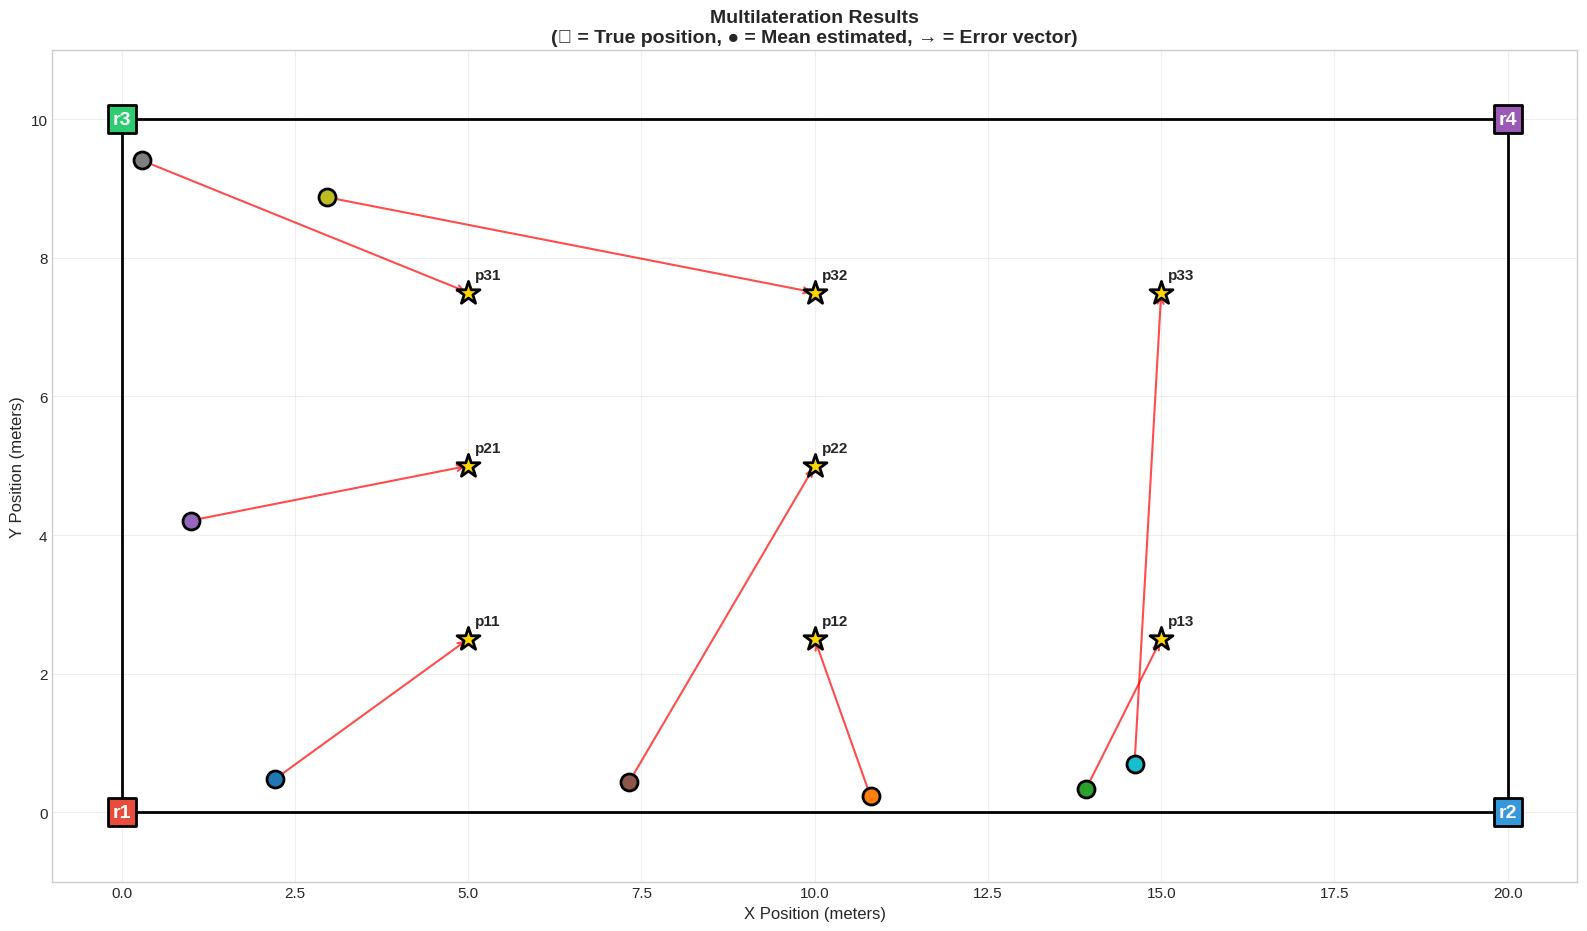

In [7]:
def plot_multilateration_results(df_results, show_all_estimates=False):
    """
    Plot multilateration results on the room layout.
    """
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Room boundary
    room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(room)
    
    # Plot responders
    resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71', 'r4': '#9b59b6'}
    for label, (x, y) in RESPONDERS.items():
        ax.scatter(x, y, s=400, c=resp_colors[label], marker='s', 
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(label, (x, y), fontsize=14, fontweight='bold',
                    ha='center', va='center', color='white', zorder=6)
    
    # Color by position for estimates
    positions = df_results['position'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(positions)))
    pos_color_map = dict(zip(positions, colors))
    
    # Plot estimates and true positions
    for pos in positions:
        pos_data = df_results[df_results['position'] == pos]
        real_x, real_y = pos_data['real_x'].iloc[0], pos_data['real_y'].iloc[0]
        
        # True position
        ax.scatter(real_x, real_y, s=300, c='gold', marker='*', 
                   edgecolor='black', linewidth=2, zorder=10, label=f'{pos} (true)')
        
        if show_all_estimates:
            # Plot all individual estimates
            ax.scatter(pos_data['est_x'], pos_data['est_y'], 
                       s=20, c=[pos_color_map[pos]], alpha=0.3, zorder=3)
        
        # Mean estimated position
        mean_est_x = pos_data['est_x'].mean()
        mean_est_y = pos_data['est_y'].mean()
        ax.scatter(mean_est_x, mean_est_y, s=150, c=[pos_color_map[pos]], 
                   marker='o', edgecolor='black', linewidth=2, zorder=8)
        
        # Error vector (arrow from estimated to true)
        ax.annotate('', xy=(real_x, real_y), xytext=(mean_est_x, mean_est_y),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7),
                    zorder=7)
        
        # Label
        ax.annotate(pos, (real_x, real_y), xytext=(5, 10), textcoords='offset points',
                    fontsize=11, fontweight='bold')
    
    ax.set_xlim(-1, 21)
    ax.set_ylim(-1, 11)
    ax.set_xlabel('X Position (meters)', fontsize=12)
    ax.set_ylabel('Y Position (meters)', fontsize=12)
    ax.set_title('Multilateration Results\n(★ = True position, ● = Mean estimated, → = Error vector)', 
                 fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

# Plot with mean estimates only
fig, ax = plot_multilateration_results(df_results, show_all_estimates=False)
plt.show()

In [ ]:
# Plot with all individual estimates (scatter cloud)
fig, ax = plot_multilateration_results(df_results, show_all_estimates=True)
ax.set_title('Multilateration Results - All Estimates\n(★ = True position, dots = individual estimates, ● = mean)', 
             fontsize=14, fontweight='bold')
plt.show()

## 8. Error Heatmap Across Room

In [ ]:
# Create error heatmap based on position
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Get mean errors per position
pos_errors = df_results.groupby('position').agg({
    'pos_error_m': 'mean',
    'real_x': 'first',
    'real_y': 'first'
}).reset_index()

# Plot 1: Position error magnitude
ax1 = axes[0]
room1 = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
ax1.add_patch(room1)

# Responders
for label, (x, y) in RESPONDERS.items():
    ax1.scatter(x, y, s=200, c='gray', marker='s', edgecolor='black', linewidth=2, zorder=5)
    ax1.annotate(label, (x, y), ha='center', va='center', color='white', fontweight='bold', zorder=6)

# Position errors as colored circles
sc1 = ax1.scatter(pos_errors['real_x'], pos_errors['real_y'], 
                  s=500, c=pos_errors['pos_error_m'], cmap='RdYlGn_r', 
                  edgecolor='black', linewidth=2, vmin=0, vmax=pos_errors['pos_error_m'].max(),
                  zorder=4)
for _, row in pos_errors.iterrows():
    ax1.annotate(f"{row['pos_error_m']:.2f}m", (row['real_x'], row['real_y']),
                 ha='center', va='center', fontsize=9, fontweight='bold')

ax1.set_xlim(-1, 21)
ax1.set_ylim(-1, 11)
ax1.set_xlabel('X (meters)')
ax1.set_ylabel('Y (meters)')
ax1.set_title('Mean Position Error by Location')
ax1.set_aspect('equal')
plt.colorbar(sc1, ax=ax1, label='Position Error (m)')

# Plot 2: Distance error by responder-position combination
ax2 = axes[1]
pivot_data = df_all.groupby(['position', 'responder_label'])['abs_error_cm'].mean().unstack()
im = ax2.imshow(pivot_data.values, cmap='RdYlGn_r', aspect='auto')
ax2.set_xticks(range(len(pivot_data.columns)))
ax2.set_xticklabels(pivot_data.columns)
ax2.set_yticks(range(len(pivot_data.index)))
ax2.set_yticklabels(pivot_data.index)
ax2.set_xlabel('Responder')
ax2.set_ylabel('Position')
ax2.set_title('Mean Absolute Distance Error (cm)\nby Position × Responder')
plt.colorbar(im, ax=ax2, label='Abs Error (cm)')

# Add text annotations
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.values[i, j]
        ax2.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Interactive Distance Rings Visualization

For a single sample, visualize the distance "rings" from each responder to see how they intersect.

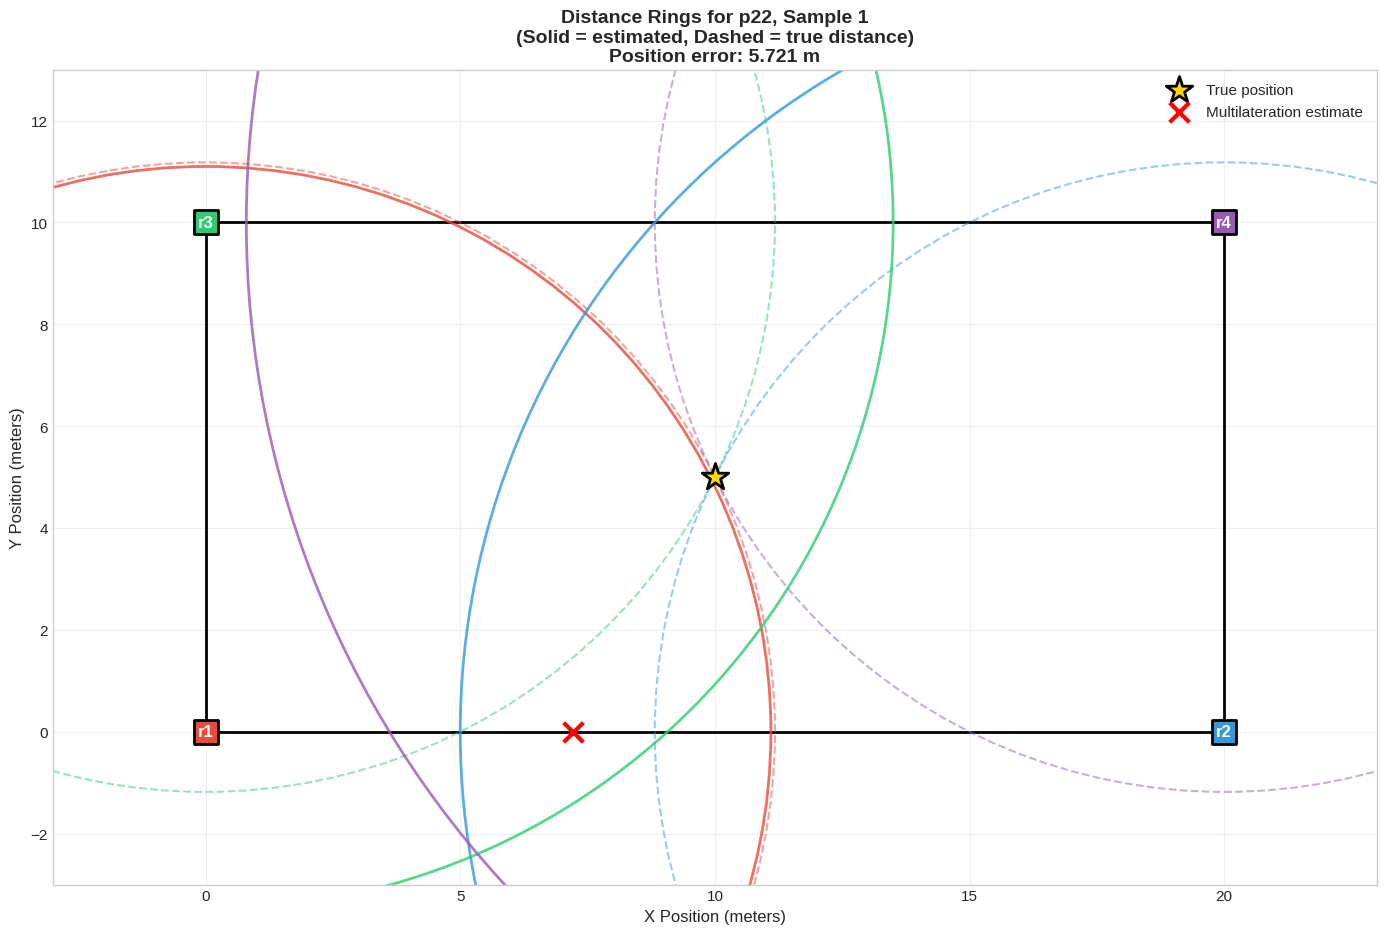

In [8]:
def plot_distance_rings(df, position, sample_num):
    """
    Visualize distance rings from each responder for a specific sample.
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Room boundary
    room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(room)
    
    # Get sample data
    mask = (df['position'] == position) & (df['sample_num'] == sample_num)
    sample_data = df[mask]
    
    if len(sample_data) == 0:
        print(f"No data for position {position}, sample {sample_num}")
        return
    
    real_x = sample_data['real_x'].iloc[0]
    real_y = sample_data['real_y'].iloc[0]
    
    resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71', 'r4': '#9b59b6'}
    
    # Plot responders and distance rings
    for _, row in sample_data.iterrows():
        label = row['responder_label']
        rx, ry = row['responder_x'], row['responder_y']
        dist_est_m = row['dist_est_cm'] / 100.0
        true_dist_m = row['true_dist_cm'] / 100.0
        
        # Responder marker
        ax.scatter(rx, ry, s=300, c=resp_colors[label], marker='s', 
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(label, (rx, ry), ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=12, zorder=6)
        
        # Estimated distance ring
        circle_est = Circle((rx, ry), dist_est_m, fill=False, 
                             edgecolor=resp_colors[label], linewidth=2, linestyle='-', alpha=0.8)
        ax.add_patch(circle_est)
        
        # True distance ring (dashed)
        circle_true = Circle((rx, ry), true_dist_m, fill=False, 
                              edgecolor=resp_colors[label], linewidth=1.5, linestyle='--', alpha=0.5)
        ax.add_patch(circle_true)
    
    # True position
    ax.scatter(real_x, real_y, s=400, c='gold', marker='*', 
               edgecolor='black', linewidth=2, zorder=10, label='True position')
    
    # Estimated position via multilateration
    est_x, est_y, _ = estimate_positions_for_sample(df, position, sample_num)
    if est_x is not None:
        ax.scatter(est_x, est_y, s=200, c='red', marker='x', linewidth=3, 
                   zorder=10, label=f'Multilateration estimate')
        pos_error = np.sqrt((est_x - real_x)**2 + (est_y - real_y)**2)
    else:
        pos_error = None
    
    ax.set_xlim(-3, 23)
    ax.set_ylim(-3, 13)
    ax.set_xlabel('X Position (meters)', fontsize=12)
    ax.set_ylabel('Y Position (meters)', fontsize=12)
    
    title = f'Distance Rings for {position}, Sample {sample_num}\n'
    title += f'(Solid = estimated, Dashed = true distance)'
    if pos_error is not None:
        title += f'\nPosition error: {pos_error:.3f} m'
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

# Example: visualize rings for position p22, sample 1
fig, ax = plot_distance_rings(df_all, 'p22', 1)
plt.show()

In [ ]:
# Try another position - corner position p11
fig, ax = plot_distance_rings(df_all, 'p11', 1)
plt.show()

## 10. Summary Statistics & Conclusions

In [9]:
print("=" * 70)
print("                    FTM MULTILATERATION SUMMARY")
print("=" * 70)

print("\n📍 TEST CONFIGURATION")
print(f"   Room dimensions: 20m × 10m")
print(f"   Responders: 4 (at corners)")
print(f"   Initiator positions tested: {len(df_all['position'].unique())}")
print(f"   Total samples: {len(df_all)}")

print("\n📏 DISTANCE ESTIMATION ACCURACY")
print(f"   Mean error: {df_all['error_cm'].mean():+.1f} cm (bias)")
print(f"   Std deviation: {df_all['error_cm'].std():.1f} cm")
print(f"   Mean absolute error: {df_all['abs_error_cm'].mean():.1f} cm")

print("\n🎯 POSITION ESTIMATION (Multilateration)")
print(f"   Mean position error: {df_results['pos_error_m'].mean():.3f} m ({df_results['pos_error_m'].mean()*100:.1f} cm)")
print(f"   Median position error: {df_results['pos_error_m'].median():.3f} m")
print(f"   Std deviation: {df_results['pos_error_m'].std():.3f} m")
print(f"   Best case (min): {df_results['pos_error_m'].min():.3f} m")
print(f"   Worst case (max): {df_results['pos_error_m'].max():.3f} m")

print("\n📊 PER-RESPONDER PERFORMANCE")
for resp in ['r1', 'r2', 'r3', 'r4']:
    mask = df_all['responder_label'] == resp
    mean_err = df_all.loc[mask, 'abs_error_cm'].mean()
    mean_rssi = df_all.loc[mask, 'rssi'].mean()
    print(f"   {resp}: Mean abs error = {mean_err:.1f} cm, Mean RSSI = {mean_rssi:.1f} dBm")

print("\n" + "=" * 70)

                    FTM MULTILATERATION SUMMARY

📍 TEST CONFIGURATION
   Room dimensions: 20m × 10m
   Responders: 4 (at corners)
   Initiator positions tested: 8
   Total samples: 31576

📏 DISTANCE ESTIMATION ACCURACY
   Mean error: +502.9 cm (bias)
   Std deviation: 478.3 cm
   Mean absolute error: 522.6 cm

🎯 POSITION ESTIMATION (Multilateration)
   Mean position error: 5.174 m (517.4 cm)
   Median position error: 5.180 m
   Std deviation: 1.994 m
   Best case (min): 0.420 m
   Worst case (max): 16.771 m

📊 PER-RESPONDER PERFORMANCE
   r1: Mean abs error = 277.4 cm, Mean RSSI = -41.4 dBm
   r2: Mean abs error = 526.9 cm, Mean RSSI = -45.0 dBm
   r3: Mean abs error = 282.6 cm, Mean RSSI = -34.7 dBm
   r4: Mean abs error = 1005.0 cm, Mean RSSI = -49.7 dBm



In [ ]:
# Save figures directory
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Re-create and save key figures
fig1, _ = plot_room_layout()
fig1.savefig(FIGURES_DIR / 'ftm_room_layout.png', dpi=150, bbox_inches='tight')

fig2, _ = plot_multilateration_results(df_results, show_all_estimates=True)
fig2.savefig(FIGURES_DIR / 'ftm_multilateration_results.png', dpi=150, bbox_inches='tight')

fig3, _ = plot_distance_rings(df_all, 'p22', 1)
fig3.savefig(FIGURES_DIR / 'ftm_distance_rings_p22.png', dpi=150, bbox_inches='tight')

print(f"Figures saved to {FIGURES_DIR.absolute()}")
plt.close('all')